## Importing libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Matplotlib is building the font cache; this may take a moment.


In [5]:

df = pd.read_csv('electricitydemand.csv')
print(df.head())

   Timestamp  hour  dayofweek  month    year  dayofyear  Temperature  \
0  01-Jan-20   0.0        2.0    1.0  2020.0        1.0     3.000000   
1  01-Jan-20   1.0        2.0    1.0  2020.0        1.0     3.000000   
2  01-Jan-20   2.0        2.0    1.0  2020.0        1.0     4.244482   
3  01-Jan-20   3.0        2.0    1.0  2020.0        1.0     3.000000   
4  01-Jan-20   4.0        2.0    1.0  2020.0        1.0     3.881208   

    Humidity       Demand  
0  61.288951  2457.119872  
1  52.873702  2269.904712  
2  36.341783  2215.640403  
3  72.629378  2174.232413  
4  90.582444  2472.453006  


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Timestamp    43848 non-null  str    
 1   hour         43837 non-null  float64
 2   dayofweek    43839 non-null  float64
 3   month        43840 non-null  float64
 4   year         43843 non-null  float64
 5   dayofyear    43843 non-null  float64
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), str(1)
memory usage: 3.0 MB


In [7]:
## Convert the 'Timestamp' column to datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

C:\Users\omara\AppData\Local\Temp\ipykernel_15452\1976015628.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Timestamp    43848 non-null  datetime64[us]
 1   hour         43837 non-null  float64       
 2   dayofweek    43839 non-null  float64       
 3   month        43840 non-null  float64       
 4   year         43843 non-null  float64       
 5   dayofyear    43843 non-null  float64       
 6   Temperature  43841 non-null  float64       
 7   Humidity     43838 non-null  float64       
 8   Demand       43841 non-null  float64       
dtypes: datetime64[us](1), float64(8)
memory usage: 3.0 MB


In [9]:
#Set the 'Timestamp' column as DataFrame index
df = df.set_index('Timestamp')

In [10]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43848 entries, 2020-01-01 to 2024-12-31
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43837 non-null  float64
 1   dayofweek    43839 non-null  float64
 2   month        43840 non-null  float64
 3   year         43843 non-null  float64
 4   dayofyear    43843 non-null  float64
 5   Temperature  43841 non-null  float64
 6   Humidity     43838 non-null  float64
 7   Demand       43841 non-null  float64
dtypes: float64(8)
memory usage: 3.0 MB


In [11]:
# Using Describe to get summary statistics of the dataset

df[['Temperature', 'Humidity', 'Demand']].describe()

,Temperature,Humidity,Demand
count,43841.000000,43838.000000,43841.000000
mean,25.067788,59.903007,5000.790976
std,12.821725,18.342604,1412.527409
min,3.000000,20.000000,1611.954020
25%,15.210186,46.241224,4015.668472
50%,25.003212,59.986720,5013.053367
75%,34.740971,73.796820,6000.803082
max,50.000000,95.000000,11910.705100


In [12]:
# Checking for missing values
print(df.isnull().sum())

hour           11
dayofweek       9
month           8
year            5
dayofyear       5
Temperature     7
Humidity       10
Demand          7
dtype: int64


In [13]:
#To show the records that contain missing values
print(df[df.isna().any(axis=1)])

            hour  dayofweek  month    year  dayofyear  Temperature   Humidity  \
Timestamp                                                                       
2020-04-30   NaN        3.0    4.0  2020.0      121.0    21.820261  41.353675   
2020-07-21   NaN        1.0    7.0  2020.0      203.0    36.555833  62.779665   
2021-02-20   NaN        NaN    NaN     NaN        NaN          NaN        NaN   
2021-02-20   NaN        NaN    NaN     NaN        NaN          NaN        NaN   
2021-02-20   NaN        NaN    NaN     NaN        NaN          NaN        NaN   
2021-02-20   NaN        NaN    NaN     NaN        NaN          NaN        NaN   
2021-02-27   NaN        5.0    2.0  2021.0       58.0    24.001003  53.303268   
2021-12-13  23.0        0.0   12.0  2021.0        NaN     3.000000  75.457130   
2021-12-14   NaN        1.0   12.0  2021.0      348.0     5.061319  47.215825   
2021-12-14  14.0        1.0   12.0  2021.0      348.0    15.403995  74.011557   
2022-06-17  13.0        4.0 

In [14]:
#To show the records that have missing values
print(df[df.isna().all(axis=1)])

            hour  dayofweek  month  year  dayofyear  Temperature  Humidity  \
Timestamp                                                                    
2021-02-20   NaN        NaN    NaN   NaN        NaN          NaN       NaN   
2021-02-20   NaN        NaN    NaN   NaN        NaN          NaN       NaN   
2021-02-20   NaN        NaN    NaN   NaN        NaN          NaN       NaN   
2021-02-20   NaN        NaN    NaN   NaN        NaN          NaN       NaN   

            Demand  
Timestamp           
2021-02-20     NaN  
2021-02-20     NaN  
2021-02-20     NaN  
2021-02-20     NaN  


In [15]:
#Dropping rows with missing values
df = df.dropna(how='all')
df

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [16]:
#To show the records that contain all null values
print(df[df.isna().all(axis=1)])

Empty DataFrame
Columns: [hour, dayofweek, month, year, dayofyear, Temperature, Humidity, Demand]
Index: []


In [17]:
# Checking for missing values
print(df.isnull().sum())

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64


In [18]:
# Checking for missing values
print(df.isnull().sum())

hour           7
dayofweek      5
month          4
year           1
dayofyear      1
Temperature    3
Humidity       6
Demand         3
dtype: int64


In [19]:
#Shape of dataset
print(df.shape)

(43844, 8)


In [20]:
df

,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
Timestamp,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,3.000000,40.565916,4015.979957


In [21]:
#create the 'Quarter' column at 5th index in the DataFrame
print(df.insert(5, 'Quarter', df.index.quarter))


None


In [22]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43837 non-null  float64
 1   dayofweek    43839 non-null  float64
 2   month        43840 non-null  float64
 3   year         43843 non-null  float64
 4   dayofyear    43843 non-null  float64
 5   Quarter      43844 non-null  int32  
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 3.2 MB


In [24]:
# Convert the datatype from float to integer of columns
df[['hour', 'dayofweek', 'month','year', 'dayofyear']] = df[['hour', 'dayofweek', 'month','year', 'dayofyear']]

In [25]:
# Check some basic information about the dataset

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43844 entries, 2020-01-01 to 2024-12-31
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour         43837 non-null  float64
 1   dayofweek    43839 non-null  float64
 2   month        43840 non-null  float64
 3   year         43843 non-null  float64
 4   dayofyear    43843 non-null  float64
 5   Quarter      43844 non-null  int32  
 6   Temperature  43841 non-null  float64
 7   Humidity     43838 non-null  float64
 8   Demand       43841 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 3.2 MB


In [26]:
df

,hour,dayofweek,month,year,dayofyear,Quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,4,3.000000,40.565916,4015.979957


In [27]:
# Create the 'Week of Year' column at 5th index in the dataset

df.insert(5, 'weekofyear', df.index.isocalendar().week.astype(int))

In [28]:
df

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,3.000000,40.565916,4015.979957


In [29]:
#To show the bottom records of the dataset
print(df.tail(50))

            hour  dayofweek  month    year  dayofyear  weekofyear  Quarter  \
Timestamp                                                                    
2024-12-29  22.0        6.0   12.0  2024.0      364.0          52        4   
2024-12-29  23.0        6.0   12.0  2024.0      364.0          52        4   
2024-12-30   0.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   1.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   2.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   3.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   4.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   5.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   6.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   7.0        0.0   12.0  2024.0      365.0           1        4   
2024-12-30   8.0        0.0   12.0  2024.0      365.0           

In [30]:
# Create a new column at 7th index to check the weekend
df.insert(7, 'is_weekend', df.index.dayofweek.isin([5, 6]).astype(int))

In [31]:
df

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957


In [32]:
#Convert the datatype of 'is_weekend' column from boolean to integer
df['is_weekend'] = df['is_weekend'].astype(int)
df

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957


In [33]:
#filtering the dataset to show only the records that are on weekends
df[df['is_weekend'] == 1]

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-04,0.0,5.0,1.0,2020.0,4.0,1,1,1,3.000000,60.955363,2067.352696
2020-01-04,1.0,5.0,1.0,2020.0,4.0,1,1,1,3.000000,66.494073,2138.504702
2020-01-04,2.0,5.0,1.0,2020.0,4.0,1,1,1,3.000000,56.398199,1880.418696
2020-01-04,3.0,5.0,1.0,2020.0,4.0,1,1,1,4.474526,60.603500,2005.823854
2020-01-04,4.0,5.0,1.0,2020.0,4.0,1,1,1,7.738184,65.808825,2203.720413
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-29,19.0,6.0,12.0,2024.0,364.0,52,4,1,7.077721,46.341323,4304.049396
2024-12-29,20.0,6.0,12.0,2024.0,364.0,52,4,1,3.000000,69.641621,4146.583958
2024-12-29,21.0,6.0,12.0,2024.0,364.0,52,4,1,3.723222,46.751731,3366.641206


In [35]:
# import Holiday library to check the holidays in the dataset
import holidays

In [42]:
# create a new column at 8th index to check the holidays, otherwise it will be 0

years = df.index.year.unique().astype(int).tolist()
holiday_calendar = holidays.IN(years=years)

df['Holiday'] = df.index.to_series().dt.date.isin(holiday_calendar).astype(int)
df

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Holiday
Timestamp,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,0
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,0
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,0
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,0
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109,0
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224,0
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957,0


In [43]:
# using value_counts() to check the number of holidays in the dataset
df.Holiday.value_counts()

Holiday
0    41924
1     1920
Name: count, dtype: int64

In [47]:
# deleting the 'Holiday' column from the dataframe if it exists
if 'Holiday' in df.columns:
	df = df.drop('Holiday', axis=1)
df

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand
Timestamp,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957


In [ ]:
# Lagged Features: These are the past values of a time series data.

# Use - Past demand values are strong predictors. They can be used as input to predict future values.

In [48]:
# Create a new column that will contain Demand from the same hour yesterday

df['Demand_lag_24hr'] = df['Demand'].shift(24)

In [49]:
# Create a new column that will contain Demand from the same hour last week

df['Demand_lag_168hr'] = df['Demand'].shift(168) # 24x7 = 168 hours for weekly shift

In [50]:
# show top rows of the dataframe

df.head(50)

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN
2020-01-01,5.0,2.0,1.0,2020.0,1.0,1,1,0,10.822571,67.753433,3104.845505,NaN,NaN
2020-01-01,6.0,2.0,1.0,2020.0,1.0,1,1,0,6.306673,94.912591,3759.476912,NaN,NaN
2020-01-01,7.0,2.0,1.0,2020.0,1.0,1,1,0,7.464640,74.456860,4114.486001,NaN,NaN
2020-01-01,8.0,2.0,1.0,2020.0,1.0,1,1,0,14.746876,66.725005,4575.159503,NaN,NaN


In [51]:
# using iloc function for the slicing of dataframe' rows

df.iloc[160:200]

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr
Timestamp,,,,,,,,,,,,,
2020-01-07,16.0,1.0,1.0,2020.0,7.0,2,1,0,14.016616,37.637752,4587.785143,4733.816549,NaN
2020-01-07,17.0,1.0,1.0,2020.0,7.0,2,1,0,6.736632,54.734906,4833.704288,4796.039663,NaN
2020-01-07,18.0,1.0,1.0,2020.0,7.0,2,1,0,17.782435,49.297649,5400.257796,4791.518998,NaN
2020-01-07,19.0,1.0,1.0,2020.0,7.0,2,1,0,3.000000,37.696671,4424.534926,4492.165854,NaN
2020-01-07,20.0,1.0,1.0,2020.0,7.0,2,1,0,7.116704,46.152197,4279.454320,4398.302015,NaN
2020-01-07,21.0,1.0,1.0,2020.0,7.0,2,1,0,5.158936,44.385460,3768.807077,3705.698515,NaN
2020-01-07,22.0,1.0,1.0,2020.0,7.0,2,1,0,3.000000,46.821530,2924.189540,3211.918549,NaN
2020-01-07,23.0,1.0,1.0,2020.0,7.0,2,1,0,3.000000,44.708096,2657.653050,2857.968639,NaN
2020-01-08,0.0,2.0,1.0,2020.0,8.0,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872


In [52]:
# Create a new column that will contain Rolling Mean of the Demand in last 24 hours

df['demand_rolling_mean_24hr'] = df['Demand'].rolling(window=24).mean()

In [53]:
# Create a new column that will contain Rolling Standard Deviation of the Demand in last 24 hours

df['demand_rolling_std_24hr'] = df['Demand'].rolling(window=24).std()

In [54]:
# show top rows of the dataframe

df.head(27)

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-01,0.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,61.288951,2457.119872,NaN,NaN,NaN,NaN
2020-01-01,1.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,52.873702,2269.904712,NaN,NaN,NaN,NaN
2020-01-01,2.0,2.0,1.0,2020.0,1.0,1,1,0,4.244482,36.341783,2215.640403,NaN,NaN,NaN,NaN
2020-01-01,3.0,2.0,1.0,2020.0,1.0,1,1,0,3.000000,72.629378,2174.232413,NaN,NaN,NaN,NaN
2020-01-01,4.0,2.0,1.0,2020.0,1.0,1,1,0,3.881208,90.582444,2472.453006,NaN,NaN,NaN,NaN
2020-01-01,5.0,2.0,1.0,2020.0,1.0,1,1,0,10.822571,67.753433,3104.845505,NaN,NaN,NaN,NaN
2020-01-01,6.0,2.0,1.0,2020.0,1.0,1,1,0,6.306673,94.912591,3759.476912,NaN,NaN,NaN,NaN
2020-01-01,7.0,2.0,1.0,2020.0,1.0,1,1,0,7.464640,74.456860,4114.486001,NaN,NaN,NaN,NaN
2020-01-01,8.0,2.0,1.0,2020.0,1.0,1,1,0,14.746876,66.725005,4575.159503,NaN,NaN,NaN,NaN


In [55]:
# Drop all Rows having null values

df = df.dropna()
df

,hour,dayofweek,month,year,dayofyear,weekofyear,Quarter,is_weekend,Temperature,Humidity,Demand,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_std_24hr
Timestamp,,,,,,,,,,,,,,,
2020-01-08,0.0,2.0,1.0,2020.0,8.0,2,1,0,3.000000,47.891592,2363.060115,2216.875986,2457.119872,3857.890516,1007.130968
2020-01-08,1.0,2.0,1.0,2020.0,8.0,2,1,0,4.433666,61.209727,2282.558766,2400.102433,2269.904712,3852.992863,1014.785101
2020-01-08,2.0,2.0,1.0,2020.0,8.0,2,1,0,5.000529,63.868618,2193.324174,2493.107375,2215.640403,3840.501897,1033.916351
2020-01-08,3.0,2.0,1.0,2020.0,8.0,2,1,0,4.253477,44.603210,2208.724679,2241.451559,2174.232413,3839.138277,1036.136212
2020-01-08,4.0,2.0,1.0,2020.0,8.0,2,1,0,5.966044,85.921008,2402.611018,2406.161001,2472.453006,3838.990361,1036.349905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31,19.0,1.0,12.0,2024.0,366.0,1,4,0,3.956838,43.287161,4689.693109,5102.077310,5105.730509,4039.969992,976.961312
2024-12-31,20.0,1.0,12.0,2024.0,366.0,1,4,0,3.118824,51.705756,4331.249224,4187.844204,4673.672173,4045.945201,978.342615
2024-12-31,21.0,1.0,12.0,2024.0,366.0,1,4,0,3.000000,40.565916,4015.979957,3859.260701,3856.359014,4052.475170,977.565114


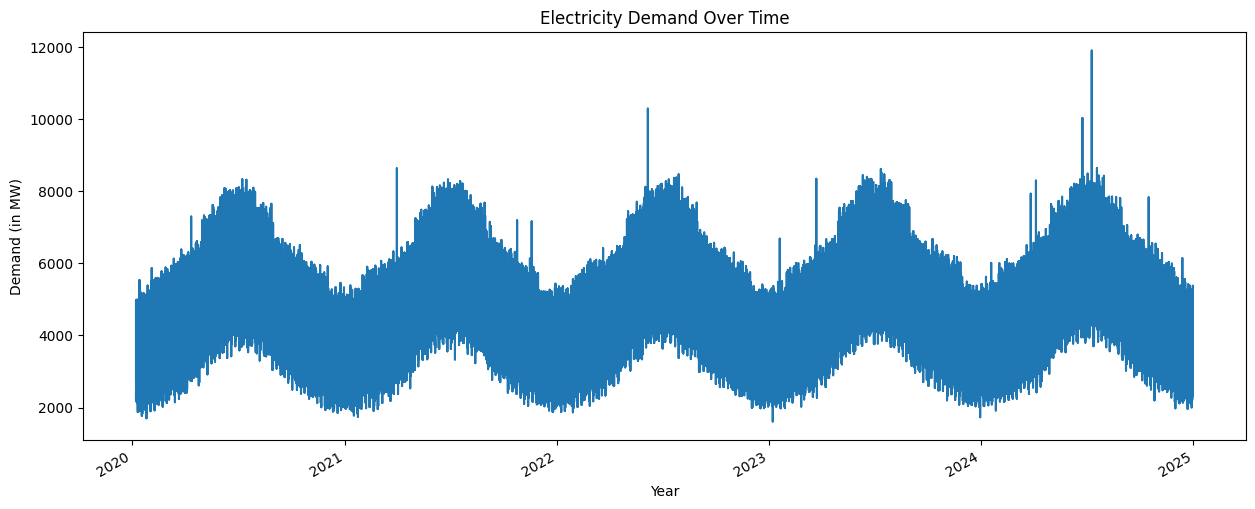

In [56]:
# Plot raw demand over time

df['Demand'].plot(figsize =(15,6), title = "Electricity Demand Over Time")
plt.xlabel("Year")                          # naming for x-axis
plt.ylabel("Demand (in MW)")                # naming for y-axis  
                   
plt.show()

In [ ]:
#visualize demand by hour of the day, using boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='hour', y='Demand')
plt.title("Electricity Demand by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Demand")
plt.show()

ValueError: Could not interpret value `hour` for `x`. Value is a string, but `data` was not passed.

<Figure size 1200x600 with 0 Axes>

In [ ]:
#visualize demand by month, using boxplot
plt.figure(figsize=(12,6))
sns.boxplot(df= df, x='month', y= 'Demand')
plt.title("Electricity Demand by Month")
plt.show()

In [ ]:
#scatter plot to visualize the relationship between temperature and demand
plt.figure(figsize=(10,6))
sns.scatterplot(df= df, x='Temperature', y= 'Demand', alpha=0.5)
plt.title("Relationship between Temperature and Electricity Demand")
plt.xlabel("Temperature")
plt.ylabel("Electricity Demand")
plt.show()

In [ ]:
# Correlation matrix and Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.show()

In [ ]:
df

In [ ]:
# Defining Target Variable (Y)

Y = data.Demand                         # target variable / dependent variable

In [ ]:
# Defining Features (X)

X = data.drop('Demand', axis=1)         # independent variables / features / predictors

In [ ]:
print (Y)           #TARGET VARIABLE
print (X)           #FEATURES

In [ ]:
# Splitting the data into Training and Testing data

X_train = X.loc[ : '2023-12-31']                  # taking 80% of data as training data

In [ ]:
X_train                                           # 80% of the training features data

In [ ]:
Y_train = Y.loc[ : '2023-12-31' ]             # taking 80% of data as training data

In [ ]:
Y_train                                       # 80% of the training target variable

In [ ]:
X_test = X.loc[ '2024-01-01' : ]               # taking 20% of data as testing data

In [ ]:
X_test                                         # 20% of the training features data  

In [ ]:
Y_test = Y.loc[ '2024-01-01' : ]                       # taking 20% of data as testing data

In [ ]:
Y_test                                                 # 20% of the testing target variable

In [ ]:
print(X_train.shape)                   
print(Y_train.shape)

In [ ]:
print(X_test.shape)
print(Y_test.shape)